# 27a · GSE135779 · scRNA_seq · gap statistic: how many groups, if any?

Reads `expression.rds`, `metadata.rds` and the GSE65391 end product `module_genes.csv`.

**Matrix.** The same as the heatmaps (notebooks 28, 29): the 33 children with SLE × the 10 GSE65391
hub genes (highest kME in GSE65391) of each GSE65391 module that are measured here, each gene z-scored
across the 33 children.

**Method.** The gap statistic (Tibshirani R, Walther G, Hastie T. Estimating the number of clusters in
a data set via the gap statistic. *J R Stat Soc B* 2001;63:411–423). For each k, it compares the
within-cluster dispersion log(W_k) of the data with its expected value under a reference
distribution that has **no clusters**:

  Gap(k) = E*[log W_k] − log W_k

E* is estimated from B reference data sets drawn uniformly over the box aligned with the data's
principal components (`spaceH0 = "scaledPCA"`, one of the two reference distributions the paper proposes).

| setting | value | reason |
|---|---|---|
| k, patients | 1 to 8 | k = 1 is included, so "no structure" is a possible answer |
| k, genes | 1 to 20 | the genes are the hub genes of the GSE65391 modules (16 modules), so the gene axis has about 16 groups by construction; the range must extend past 16 for the answer to fall inside it |
| B | 500 reference data sets | the package default is 100; more reference sets reduce the Monte Carlo error of E*[log W_k] (the reported SE includes the factor √(1 + 1/B)) |
| d.power | 2 | squared Euclidean distances; the `clusGap` documentation: `d.power = 2` "corresponds to what Tibshirani et al had proposed" (the default, 1, is the historical R implementation) |
| rule | `Tibs2001SEmax` | the paper's rule: the smallest k with Gap(k) ≥ Gap(k+1) − SE(k+1); it returns k = 1 when no larger k improves Gap by more than its standard error |

**Clustering method: k-means only**, on **both axes** (patients as observations; genes as
observations), 50 random starts.

**Why k-means only.** k, the number of clusters, is an input of k-means (Lloyd SP. Least squares
quantization in PCM. *IEEE Trans Inf Theory* 1982;28:129–137, doi:10.1109/TIT.1982.1056489; R's
`kmeans` uses Hartigan JA, Wong MA. Algorithm AS 136. *J R Stat Soc C* 1979;28:100–108,
doi:10.2307/2346830), so a rule for choosing k is needed and the gap statistic is such a rule. Ward's
hierarchical clustering (Ward JH. *J Am Stat Assoc* 1963;58:236–244, doi:10.1080/01621459.1963.10500845;
the `ward.D2` implementation: Murtagh F, Legendre P. *J Classif* 2014;31:274–295,
doi:10.1007/s00357-014-9161-z) has no k: its result is the whole tree. Cutting the tree at a chosen k
is an extra step the method does not make. Whether branches of the tree are supported is assessed
separately, by bootstrap (pvclust-py) and by tree shape (Dynamic Tree Cut), in their own notebooks.

The gap statistic is computed with `cluster::clusGap` (Maechler M et al., R package `cluster`),
which implements Tibshirani et al. (2001) and documents the settings below.

**Reading.** k = 1 means the data are no more clustered than the no-cluster reference.

In [1]:
source("../src/paths.R")
suppressMessages(library(cluster))
x    <- readRDS(art("GSE135779", "expression.rds"))
meta <- readRDS(art("GSE135779", "metadata.rds"))
mg   <- read.csv(art("GSE65391", "module_genes.csv"))
sle  <- rownames(meta)[meta$sle == 1]
hub  <- do.call(rbind, lapply(split(mg, mg$module), function(d) head(d[order(-d$kME), ], 10)))
hub  <- hub$gene[hub$gene %in% rownames(x$E)]
X    <- scale(t(x$E[hub, sle]))                   # children x genes, z-score per gene
X    <- X[, colSums(is.na(X)) == 0]
dim(X)

[1]  33 121

In [2]:
km_fun   <- function(x, k) list(cluster = if (k == 1) rep(1L, nrow(x)) else kmeans(x, k, nstart = 50, iter.max = 100)$cluster)
gap_run  <- function(x, fun, K.max) { set.seed(SEED); clusGap(x, FUNcluster = fun, K.max = K.max, B = 500, d.power = 2, spaceH0 = "scaledPCA", verbose = FALSE) }
gaps <- list(
  "patients, k-means" = gap_run(X, km_fun, K.max = 8),
  "genes, k-means"    = gap_run(t(X), km_fun, K.max = 20))

**Result table.** Gap(k) and its standard error for every k; the k chosen by the 1-SE rule.

In [3]:
for (nm in names(gaps)) {
  g <- gaps[[nm]]$Tab
  print(data.frame(axis = nm, k = seq_len(nrow(g)), gap = round(g[, "gap"], 4), SE = round(g[, "SE.sim"], 4)))
}
chosen <- sapply(gaps, function(g) maxSE(g$Tab[, "gap"], g$Tab[, "SE.sim"], method = "Tibs2001SEmax"))
chosen

               axis k    gap     SE
1 patients, k-means 1 0.4503 0.0577
2 patients, k-means 2 0.3882 0.0539
3 patients, k-means 3 0.3724 0.0484
4 patients, k-means 4 0.3630 0.0486
5 patients, k-means 5 0.3608 0.0491
6 patients, k-means 6 0.3616 0.0507
7 patients, k-means 7 0.3674 0.0518
8 patients, k-means 8 0.3861 0.0528
             axis  k    gap     SE
1  genes, k-means  1 0.5656 0.0217
2  genes, k-means  2 0.6450 0.0211
3  genes, k-means  3 0.7681 0.0211
4  genes, k-means  4 0.8228 0.0210
5  genes, k-means  5 0.8862 0.0211
6  genes, k-means  6 0.9296 0.0209
7  genes, k-means  7 0.9606 0.0209
8  genes, k-means  8 0.9968 0.0208
9  genes, k-means  9 1.0258 0.0209
10 genes, k-means 10 1.0501 0.0209
11 genes, k-means 11 1.0702 0.0209
12 genes, k-means 12 1.0864 0.0206
13 genes, k-means 13 1.1025 0.0208
14 genes, k-means 14 1.1123 0.0209
15 genes, k-means 15 1.1185 0.0209
16 genes, k-means 16 1.1267 0.0209
17 genes, k-means 17 1.1301 0.0211
18 genes, k-means 18 1.1368 0.0211
19 genes, k

patients, k-means    genes, k-means 
                1                10

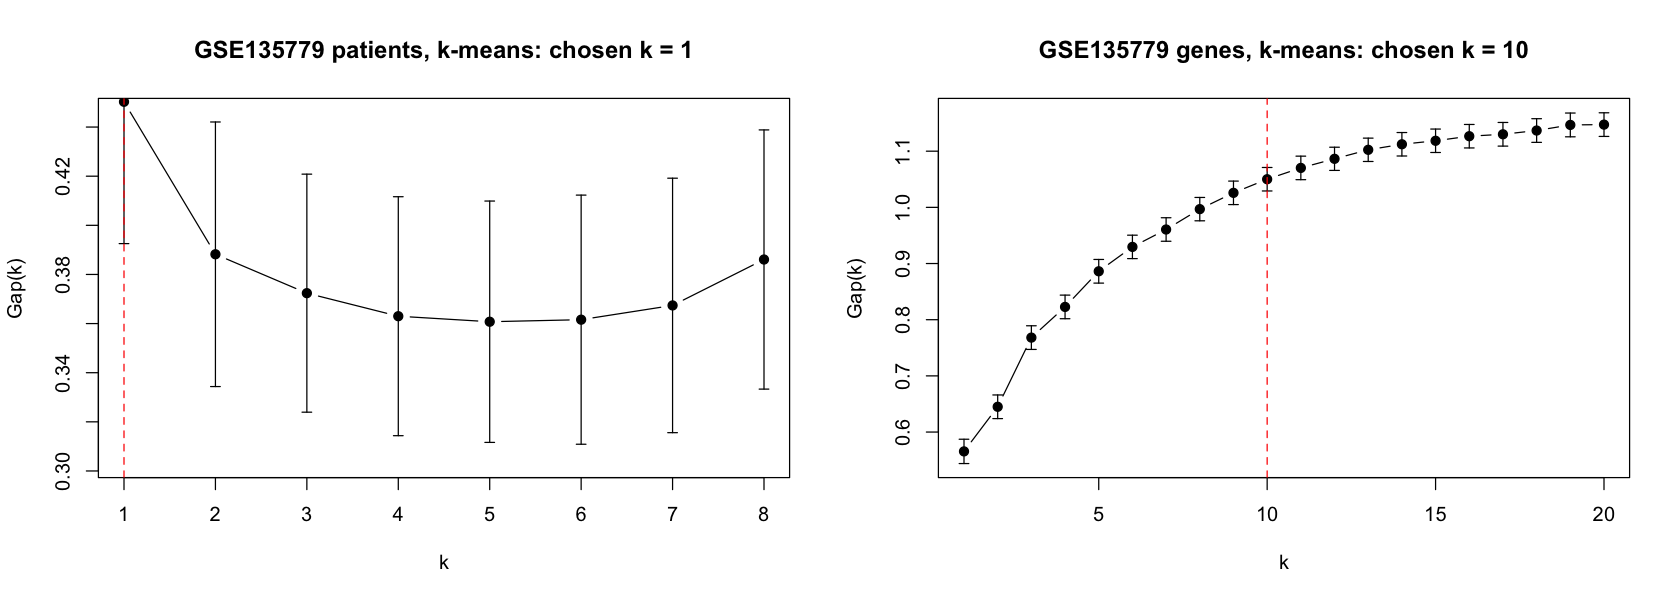

In [4]:
options(repr.plot.width = 14, repr.plot.height = 5)
par(mfrow = c(1, 2))
for (nm in names(gaps)) {
  g <- gaps[[nm]]$Tab
  k <- seq_len(nrow(g))
  plot(k, g[, "gap"], type = "b", pch = 19, ylim = range(g[, "gap"] + c(-1, 1) * max(g[, "SE.sim"])),
       xlab = "k", ylab = "Gap(k)", main = sprintf("GSE135779 %s: chosen k = %d", nm, chosen[[nm]]))
  arrows(k, g[, "gap"] - g[, "SE.sim"], k, g[, "gap"] + g[, "SE.sim"], angle = 90, code = 3, length = 0.04)
  abline(v = chosen[[nm]], lty = 2, col = "red")
}

In [5]:
saveRDS(list(gaps = gaps, chosen = chosen), art("GSE135779", "gap_statistic.rds"))